In [21]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

### Functions for the Data Pipeline

In [2]:
# function to get list of all race id in a season
# series key for now is 'series_1' for cup, 'series_2' for xfinity, 'series_3' for trucks
def get_race_ids(year, series_key):

    race_list_url = f"https://cf.nascar.com/cacher/{year}/race_list_basic.json"
    response = requests.get(race_list_url)
    data = response.json()
    races_df = pd.DataFrame(data[series_key])
    races_df_clean = races_df[['race_id', 'series_id', 'race_season', 'track_id', 'race_name', 'race_type_id', 'actual_laps']]
    return races_df_clean


In [3]:
# function to get track information 
def get_track_info():
    track_info_url = "https://cf.nascar.com/cacher/tracks.json"
    response = requests.get(track_info_url)
    data = response.json()
    df = pd.DataFrame(data['items'])
    df = df[['track_id', 'track_name', 'track_surface', 'track_type']]
    return df

In [4]:
# function to get lap data for a single race
def fetch_single_race(year,series_num, race_id):
    race_url = f"https://cf.nascar.com/cacher/{year}/{series_num}/{race_id}/lap-times.json"
    response = requests.get(race_url)
    data = response.json()
    # pull out lap data and create a row for each driver lap time
    df = pd.json_normalize(
        data['laps'],
        record_path='Laps',
        meta=['Number', 'FullName', 'NASCARDriverID']
    )
    # will need to adjust the flag key if more flag states are added in the future
    flag_key = {
    0: 'None',
    1: 'Green',
    2: 'Yellow',
    3: 'Red',
    4: 'White',
    5: 'Checkered',
    8: 'Hot Track',
    9: 'Cold Track'}
    # create a dataframe for flag status and merge it with the lap data
    flag_status = pd.DataFrame(data['flags'])
    flag_status["FlagName"] = flag_status["FlagState"].map(flag_key).fillna("Unknown")
    df = pd.merge(df, flag_status, left_on = 'Lap', right_on = 'LapsCompleted', how = 'left')

    return df

# function to get lap data for a list of races
def get_lap_data(year, series_num, race_ids):
    lap_data = []
    # run the single race function above for each race id
    for race_id in race_ids: 
        race_data = fetch_single_race(year, series_num,race_id)
        race_data['race_id'] = race_id
        lap_data.append(race_data)

    lap_df = pd.concat(lap_data, ignore_index=True)
    return lap_df

In [5]:

# function to get result data for a single race
def fetch_single_result(year,series_num, race_id):
    race_url = f"https://cf.nascar.com/loopstats/prod/{year}/{series_num}/{race_id}.json"
    response = requests.get(race_url)
    data = response.json()
    # pull out lap data and create a row for each driver lap time
    df = pd.json_normalize(
        data,
        record_path='drivers',
        meta=['race_id']
    )
    df = df[['driver_id', 'ps', 'laps', 'race_id']]

    return df

# using the result function for each race in the season to get a df of all results
def get_result_data(year, series_num, race_ids):
    result_data = []
    # run the single race function above for each race id
    for race_id in race_ids: 
        race_data = fetch_single_result(year, series_num,race_id)
        race_data['race_id'] = race_id
        result_data.append(race_data)

    result_df = pd.concat(result_data, ignore_index=True)
    return result_df


In [6]:
# function to get pit data for each race 

def fetch_pit_data(series_num, race_ids):

    #races_df = races_df[races_df['race_type_id'] == 1] 

    def fetch_single_race(series_num, race_id):
        pit_url = f"https://cf.nascar.com/cacher/live/series_{series_num}/{race_id}/live-pit-data.json"
        response = requests.get(pit_url)
        data = response.json()
        return pd.DataFrame(data)

    pit_data = []
    for race_id in race_ids:
        race_data = fetch_single_race(series_num,race_id)
        race_data['race_id'] = race_id
        pit_data.append(race_data)

    pit_df = pd.concat(pit_data, ignore_index=True)
    pit_df = pit_df[['vehicle_number', 'lap_count', 'pit_stop_type', 'left_front_tire_changed', 'right_front_tire_changed', 'left_rear_tire_changed', 'right_rear_tire_changed', 'race_id']]

    return pit_df

### Fetching Data 

In [46]:

year = 2025
series_key = 'series_1'
series_num = 1

# running the function to get the race IDs for the season
races = get_race_ids(year, series_key)
races = races[races['race_type_id'] ==1]
# create a list of race ids
race_ids = races['race_id'].tolist()


# get tracking infromation
track_df = get_track_info()

# merginging track information with the race information
races = races.merge(track_df, on='track_id', how='left')

# get lap data for each race in the season
lap_df = get_lap_data(year, series_num, race_ids)

# get result data for each race in the season
results = get_result_data(year, series_num, race_ids)

# get pit data for the season
pit_df = fetch_pit_data(series_num,race_ids)



In [47]:
# merging the results df with the lap data to get result for each race
merged_df = lap_df.merge(results, left_on=['race_id', 'NASCARDriverID'], right_on= ['race_id', 'driver_id'])
races_clean = races[['race_id', 'track_type']]
merged_df = merged_df.merge(races_clean, left_on=['race_id'], right_on=['race_id'])
merged_df.head()

,Lap,LapTime,LapSpeed,RunningPos,Number,FullName,NASCARDriverID,LapsCompleted,FlagState,FlagName,race_id,driver_id,ps,laps,track_type
0,0,NaN,NaN,5,24,William Byron,4184,0.0,8.0,Hot Track,5546,4184,1,201,Superspeedway
1,1,52.135,172.629,5,24,William Byron,4184,1.0,1.0,Green,5546,4184,1,201,Superspeedway
2,2,47.861,188.045,5,24,William Byron,4184,2.0,1.0,Green,5546,4184,1,201,Superspeedway
3,3,47.966,187.633,4,24,William Byron,4184,3.0,1.0,Green,5546,4184,1,201,Superspeedway
4,4,47.957,187.668,2,24,William Byron,4184,4.0,1.0,Green,5546,4184,1,201,Superspeedway


In [24]:
df = merged_df.merge(pit_df, left_on= ['race_id', 'Number', 'Lap'], right_on= ['race_id', 'vehicle_number', 'lap_count'], how='left')

In [10]:
df.head()

,Lap,LapTime,LapSpeed,RunningPos,Number,FullName,NASCARDriverID,LapsCompleted,FlagState,FlagName,...,ps,laps,track_type,vehicle_number,lap_count,pit_stop_type,left_front_tire_changed,right_front_tire_changed,left_rear_tire_changed,right_rear_tire_changed
0,0,NaN,NaN,5,24,William Byron,4184,0.0,8.0,Hot Track,...,1,201,Superspeedway,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,52.135,172.629,5,24,William Byron,4184,1.0,1.0,Green,...,1,201,Superspeedway,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,47.861,188.045,5,24,William Byron,4184,2.0,1.0,Green,...,1,201,Superspeedway,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,47.966,187.633,4,24,William Byron,4184,3.0,1.0,Green,...,1,201,Superspeedway,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,47.957,187.668,2,24,William Byron,4184,4.0,1.0,Green,...,1,201,Superspeedway,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Feature Engineering

In [25]:
df.columns

Index(['Lap', 'LapTime', 'LapSpeed', 'RunningPos', 'Number', 'FullName',
       'NASCARDriverID', 'LapsCompleted', 'FlagState', 'FlagName', 'race_id',
       'driver_id', 'ps', 'laps', 'track_type', 'vehicle_number', 'lap_count',
       'pit_stop_type', 'left_front_tire_changed', 'right_front_tire_changed',
       'left_rear_tire_changed', 'right_rear_tire_changed'],
      dtype='str')

In [26]:
df = df.drop(columns = ['NASCARDriverID', 'lap_count', 'LapsCompleted', 'vehicle_number'])

# adding pit stop binary column
df['PitStop'] = df['pit_stop_type'].notnull().astype(int)
df = df.rename(columns={'ps': 'Finish Position', 'Running Pos': 'Position', 'laps': 'Total Laps'})

In [27]:
#df = df[df['FlagName'] == "Green"]



# removing punctuations from lap speed and converting to float
df = df.replace({'LapSpeed': {',': ''}}, regex=True)
# replace NaN in LapSpeed to 0 
df = df.fillna(0)
df = df.astype({'LapSpeed': 'float', 'left_front_tire_changed': 'float', 'right_front_tire_changed': 'float', 'left_rear_tire_changed': 'float', 'right_rear_tire_changed': 'float'})

df['Avg LapSpeed'] = df.groupby(['race_id', 'Lap'])['LapSpeed'].transform('median')
df['Diff to Avg LapSpeed'] = df['LapSpeed'] - df['Avg LapSpeed']

df['Pct of Race Completed'] = df['Lap'] / df['Total Laps']

df['Speed Rank'] = df.groupby(["race_id","Lap"])["LapSpeed"].rank(ascending=False).astype(int)


df = df.sort_values(["race_id", "driver_id", "Lap"])


df['Number of Tires Changed'] = (df['left_front_tire_changed'] + df['right_front_tire_changed'] 
            + df['left_rear_tire_changed'] + df['right_rear_tire_changed'])

df['Tire Change'] = (df['Number of Tires Changed'] > 0).astype(int)

df["tire_stint"] = (
    df.groupby(["race_id", "driver_id"])["Tire Change"]
      .cumsum()
)

df["pit_stint"] = (
    df.groupby(["race_id", "driver_id"])["PitStop"]
      .cumsum()
)

df["Laps Since Pit"] = (
    df.groupby(["race_id", "driver_id","pit_stint"])
      .cumcount()
)


df["Tire Age"] = (
    df.groupby(["race_id", "driver_id", "tire_stint"])
      .cumcount()
)

df['Avg Tire Age'] = df.groupby(['race_id', 'Lap'])['Tire Age'].transform('mean')

df["Is Leader"] = (df["RunningPos"] == 1).astype(int)

df["Laps Led"] = (
    df.groupby(["race_id","driver_id"])["Is Leader"]
      .cumsum()
)

df["Avg Position L5"] = (
    df.groupby(["race_id", "driver_id"])["RunningPos"]
      .transform(
          lambda x: x.shift(1).rolling(5, min_periods=1).mean()
      )
)

df["Avg Speed L5"] = (
    df.groupby(["race_id", "driver_id"])["Speed Rank"]
      .transform(
          lambda x: x.shift(1).rolling(5, min_periods=1).mean()
      )
)

df["Avg Speed L15"] = (
    df.groupby(["race_id", "driver_id"])["Speed Rank"]
      .transform(
          lambda x: x.shift(1).rolling(15, min_periods=1).mean()
      )
)

df["Position Change 5"] = (
    df.groupby(["race_id","driver_id"])["RunningPos"]
      .shift(5)
      .sub(df["RunningPos"])
)

df["Position Change 15"] = (
    df.groupby(["race_id","driver_id"])["RunningPos"]
      .shift(15)
      .sub(df["RunningPos"])
)


df["Avg Position"] = (
    df.groupby(["race_id", "driver_id"])["RunningPos"]
      .expanding()
      .mean()
      .reset_index(level=[0, 1], drop=True)
)

df["Is Caution"] = (df["FlagName"] == "Yellow").astype(int)
df["Is Green"] = (df["FlagName"] == "Green").astype(int)

df["Is Restart"] = (
    df.groupby(["race_id", "driver_id"])["FlagName"]
      .transform(lambda x: (x == "Green") & (x.shift(1) != "Green"))
)

df["restart_segment"] = (
    df.groupby(["race_id", "driver_id"])["Is Restart"]
      .cumsum()
)

df["LapsSinceRestart"] = (
    df.groupby(["race_id", "driver_id", "restart_segment"])
      .cumcount()
)

df["LapsSinceRestart"] = np.where(
    df["Is Green"] == 1,
    df["LapsSinceRestart"],
    0
)

def restart_phase(x):
    if x <= 3:
        return 0  
    elif x <= 10:
        return 1  
    elif x <= 25:
        return 2  
    else:
        return 3 

df["RestartPhase"] = df["LapsSinceRestart"].apply(restart_phase)

df["Winner"] = (df["Finish Position"] <= 3).astype(int)

df = df.fillna(0)
df['Tire Age Difference'] = df['Tire Age'] - df['Avg Tire Age']
df.head()

,Lap,LapTime,LapSpeed,RunningPos,Number,FullName,FlagState,FlagName,race_id,driver_id,...,Position Change 15,Avg Position,Is Caution,Is Green,Is Restart,restart_segment,LapsSinceRestart,RestartPhase,Winner,Tire Age Difference
1618,0,0.000,0.000,19,40,* Justin Allgaier(i),8.0,Hot Track,5546,34,...,0.0,19.000000,0,0,False,0,0,0,0,0.0
1619,1,51.734,173.967,20,40,* Justin Allgaier(i),1.0,Green,5546,34,...,0.0,19.500000,0,1,True,1,0,0,0,0.0
1620,2,47.738,188.529,19,40,* Justin Allgaier(i),1.0,Green,5546,34,...,0.0,19.333333,0,1,False,1,1,0,0,0.0
1621,3,47.830,188.166,19,40,* Justin Allgaier(i),1.0,Green,5546,34,...,0.0,19.250000,0,1,False,1,2,0,0,0.0
1622,4,48.042,187.336,18,40,* Justin Allgaier(i),1.0,Green,5546,34,...,0.0,19.000000,0,1,False,1,3,0,0,0.0


In [14]:
df.columns

Index(['Lap', 'LapTime', 'LapSpeed', 'RunningPos', 'Number', 'FullName',
       'FlagState', 'FlagName', 'race_id', 'driver_id', 'Finish Position',
       'Total Laps', 'track_type', 'pit_stop_type', 'left_front_tire_changed',
       'right_front_tire_changed', 'left_rear_tire_changed',
       'right_rear_tire_changed', 'PitStop', 'Avg LapSpeed',
       'Diff to Avg LapSpeed', 'Pct of Race Completed', 'Speed Rank',
       'Number of Tires Changed', 'Tire Change', 'tire_stint', 'pit_stint',
       'Laps Since Pit', 'Tire Age', 'Avg Tire Age', 'Is Leader', 'Laps Led',
       'Avg Position L5', 'Avg Speed L5', 'Avg Speed L15', 'Position Change 5',
       'Position Change 15', 'Avg Position', 'Is Caution', 'Is Green',
       'Is Restart', 'restart_segment', 'LapsSinceRestart', 'RestartPhase',
       'Winner', 'Tire Age Difference'],
      dtype='str')

In [31]:
clean_df = df[['race_id','RunningPos','Speed Rank','LapSpeed','Diff to Avg LapSpeed','Pct of Race Completed','Laps Since Pit','Tire Age','Avg Speed L5','Avg Speed L15','Position Change 5','Position Change 15','LapsSinceRestart',
    'RestartPhase','Is Green','Laps Led','Winner']]

In [32]:
x = clean_df.drop(columns = ['Winner'])
y = df[['Winner']]

In [33]:
print(y.head())
x.head(30)

      Winner
1618       0
1619       0
1620       0
1621       0
1622       0


,race_id,RunningPos,Speed Rank,LapSpeed,Diff to Avg LapSpeed,Pct of Race Completed,Laps Since Pit,Tire Age,Avg Speed L5,Avg Speed L15,Position Change 5,Position Change 15,LapsSinceRestart,RestartPhase,Is Green,Laps Led
1618,5546,19,21,0.000,0.000,0.000000,0,0,0.0,0.000000,0.0,0.0,0,0,0,0
1619,5546,20,11,173.967,0.346,0.004975,1,1,21.0,21.000000,0.0,0.0,0,0,1,0
1620,5546,19,19,188.529,0.260,0.009950,2,2,16.0,16.000000,0.0,0.0,1,0,1,0
1621,5546,19,9,188.166,0.290,0.014925,3,3,17.0,17.000000,0.0,0.0,2,0,1,0
1622,5546,18,10,187.336,0.300,0.019900,4,4,15.0,15.000000,0.0,0.0,3,0,1,0
1623,5546,16,8,187.056,0.454,0.024876,5,5,14.0,14.000000,3.0,0.0,4,1,1,0
1624,5546,20,32,186.370,-0.627,0.029851,6,6,11.4,13.000000,0.0,0.0,5,1,1,0
1625,5546,20,19,188.478,0.016,0.034826,7,7,15.6,15.714286,-1.0,0.0,6,1,1,0
1626,5546,22,21,188.525,0.000,0.039801,8,8,15.6,16.125000,-3.0,0.0,7,1,1,0
1627,5546,25,30,185.862,-0.678,0.044776,9,9,18.0,16.666667,-7.0,0.0,0,0,0,0


In [34]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(x, y, groups=clean_df["race_id"])
)

X_train = x.iloc[train_idx]
X_test = x.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

In [35]:

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced")

model.fit(X_train, y_train)

preds = model.predict_proba(X_test)[:,1]

c:\Users\JG06982\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\JG06982\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [36]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, preds)

print(f"AUC: {auc:.3f}")

AUC: 0.822


In [37]:
from sklearn.metrics import confusion_matrix
y_pred = (preds >= 0.7).astype(int)
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[59574  8878]
 [ 2551  3726]]


In [38]:
df_test = df.iloc[test_idx].copy()

df_test["win_probability"] = preds

In [40]:
df_test.head()

,Lap,LapTime,LapSpeed,RunningPos,Number,FullName,FlagState,FlagName,race_id,driver_id,...,Avg Position,Is Caution,Is Green,Is Restart,restart_segment,LapsSinceRestart,RestartPhase,Winner,Tire Age Difference,win_probability
67316,0,0.000,0.000,8,8,Kyle Busch,8.0,Hot Track,5558,454,...,8.000000,0,0,False,0,0,0,0,0.0,0.786356
67317,1,31.245,157.388,7,8,Kyle Busch,1.0,Green,5558,454,...,7.500000,0,1,True,1,0,0,0,0.0,0.796340
67318,2,30.014,163.844,7,8,Kyle Busch,1.0,Green,5558,454,...,7.333333,0,1,False,1,1,0,0,0.0,0.835863
67319,3,30.267,162.474,7,8,Kyle Busch,1.0,Green,5558,454,...,7.250000,0,1,False,1,2,0,0,0.0,0.843215
67320,4,34.644,141.947,7,8,Kyle Busch,2.0,Yellow,5558,454,...,7.200000,1,0,False,1,0,0,0,0.0,0.843328


In [41]:
race_id = 5558
driver_id = 454	

d = df_test[
    (df_test["race_id"] == race_id) &
    (df_test["driver_id"] == driver_id)
].copy()

In [43]:
d = d.sort_values("Lap")
#print(d[["Lap", "RunningPos", "win_probability"]].tail(30))
d.tail(20)

,Lap,LapTime,LapSpeed,RunningPos,Number,FullName,FlagState,FlagName,race_id,driver_id,...,Is Caution,Is Green,Is Restart,restart_segment,LapsSinceRestart,RestartPhase,Winner,Tire Age Difference,win_probability,win_prob_smooth
67594,278,31.768,154.797,11,8,Kyle Busch,1.0,Green,5558,454,...,0,1,False,8,77,3,0,-1.028571,0.527533,0.515554
67595,279,32.085,153.268,11,8,Kyle Busch,1.0,Green,5558,454,...,0,1,False,8,78,3,0,-1.028571,0.501919,0.515124
67596,280,32.138,153.015,11,8,Kyle Busch,1.0,Green,5558,454,...,0,1,False,8,79,3,0,-1.028571,0.513124,0.516604
67597,281,32.200,152.720,11,8,Kyle Busch,1.0,Green,5558,454,...,0,1,False,8,80,3,0,-1.941176,0.521145,0.517046
67598,282,32.018,153.589,11,8,Kyle Busch,1.0,Green,5558,454,...,0,1,False,8,81,3,0,-1.941176,0.528956,0.518536
67599,283,32.237,152.545,11,8,Kyle Busch,1.0,Green,5558,454,...,0,1,False,8,82,3,0,-1.941176,0.526471,0.518323
67600,284,32.182,152.806,11,8,Kyle Busch,1.0,Green,5558,454,...,0,1,False,8,83,3,0,-1.941176,0.524930,0.522925
67601,285,32.631,150.703,11,8,Kyle Busch,1.0,Green,5558,454,...,0,1,False,8,84,3,0,-1.941176,0.491326,0.518566
67602,286,32.673,150.510,11,8,Kyle Busch,1.0,Green,5558,454,...,0,1,False,8,85,3,0,-1.941176,0.478821,0.510101
67603,287,32.967,149.167,10,8,Kyle Busch,1.0,Green,5558,454,...,0,1,False,8,86,3,0,-1.941176,0.476150,0.499540


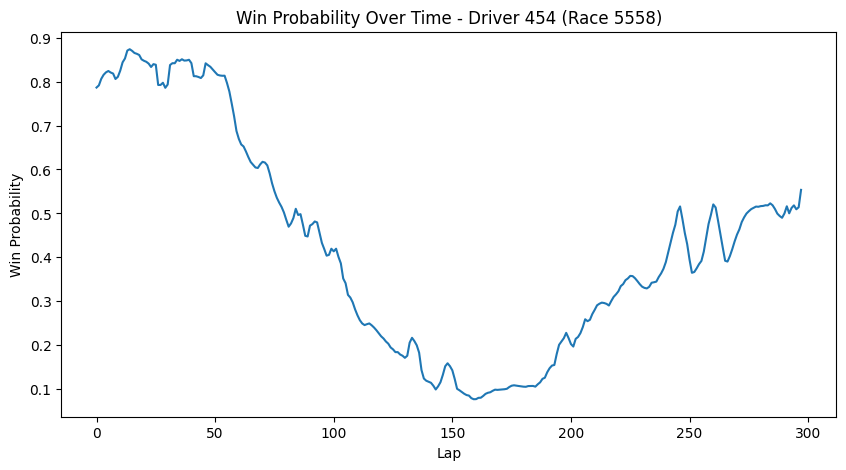

In [42]:
import matplotlib.pyplot as plt
d["win_prob_smooth"] = (
    d["win_probability"]
    .rolling(5, min_periods=1)
    .mean()
)

plt.figure(figsize=(10,5))

plt.plot(d["Lap"], d["win_prob_smooth"])

plt.xlabel("Lap")
plt.ylabel("Win Probability")
plt.title(f"Win Probability Over Time - Driver {driver_id} (Race {race_id})")

plt.show()

In [206]:
races[races["race_id"] == 5558]

,race_id,series_id,race_season,track_id,race_name,race_type_id,actual_laps,track_name,track_surface,track_type
7,5558,1,2025,4,Goodyear 400,1,297,Darlington Raceway,Asphalt,Intermediate


In [208]:
d[100:150]

,Lap,LapTime,LapSpeed,RunningPos,Number,FullName,FlagState,FlagName,race_id,driver_id,...,Is Caution,Is Green,Is Restart,restart_segment,LapsSinceRestart,RestartPhase,Winner,Tire Age Difference,win_probability,win_prob_smooth
64734,100,31.013,158.566,17,11,Denny Hamlin,1.0,Green,5558,1361,...,0,1,False,5,2,0,1,3.621622,0.420350,0.331476
64735,101,30.882,159.238,17,11,Denny Hamlin,1.0,Green,5558,1361,...,0,1,False,5,3,0,1,3.621622,0.318178,0.330271
64736,102,30.826,159.528,16,11,Denny Hamlin,1.0,Green,5558,1361,...,0,1,False,5,4,1,1,3.621622,0.322018,0.329492
64737,103,30.938,158.950,16,11,Denny Hamlin,1.0,Green,5558,1361,...,0,1,False,5,5,1,1,4.162162,0.323595,0.341205
64738,104,30.813,159.595,15,11,Denny Hamlin,1.0,Green,5558,1361,...,0,1,False,5,6,1,1,4.162162,0.384114,0.353651
64739,105,30.930,158.991,15,11,Denny Hamlin,1.0,Green,5558,1361,...,0,1,False,5,7,1,1,4.162162,0.385110,0.346603
64740,106,31.108,158.082,15,11,Denny Hamlin,1.0,Green,5558,1361,...,0,1,False,5,8,1,1,4.162162,0.378166,0.358601
64741,107,31.146,157.889,15,11,Denny Hamlin,1.0,Green,5558,1361,...,0,1,False,5,9,1,1,4.162162,0.384724,0.371142
64742,108,31.043,158.413,15,11,Denny Hamlin,1.0,Green,5558,1361,...,0,1,False,5,10,1,1,4.162162,0.392480,0.384919
64743,109,31.242,157.403,15,11,Denny Hamlin,1.0,Green,5558,1361,...,0,1,False,5,11,2,1,4.162162,0.375692,0.383235
